In [1]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

In [4]:
# Load the dataset
df = pd.read_csv("data/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### The dataset contains information about individuals and their medical insurance charges.

In [5]:
df.shape

(1338, 7)

### Dataset contains 1338 rows and 7 columns.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- ### Numerical columns: age, bmi, children, charges

- ### Categorical columns: sex, smoker, region

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


- ### Average age around 39

- ### Average BMI around 30 (Overweight range)

- ### Average charges around 13270

- ### Charges have high standard deviation → Indicates variability

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## No missing values found in the dataset.
### Therefore, no data imputation required.

# Univariate Analysis (Distribution of Each Column)

# Age Distribution

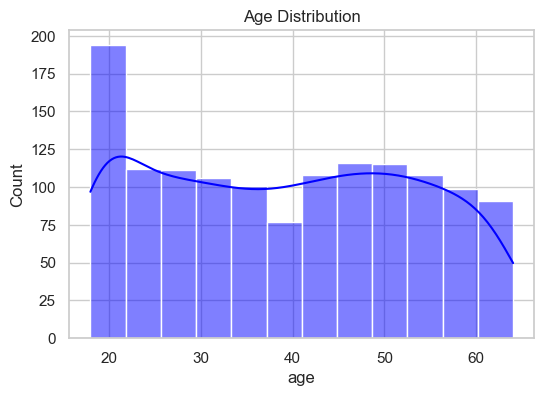

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True, color='blue')
plt.title("Age Distribution")
plt.show()

- ### Age distribution is fairly uniform.

- ### Most individuals fall between 20–60 years.

## BMI Distribution

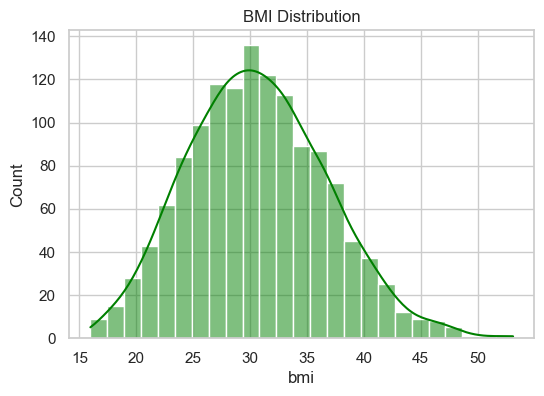

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], kde=True, color='green')
plt.title("BMI Distribution")
plt.show()

- ### Most BMI values range between 25–35.

- ### Indicates majority are overweight.

## Charges Distribution

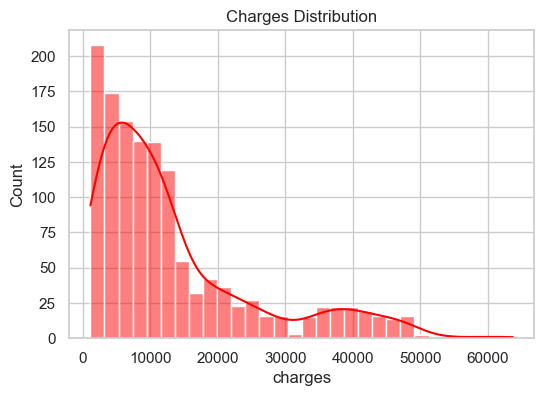

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], kde=True, color='red')
plt.title("Charges Distribution")
plt.show()

- ### Charges are heavily right-skewed.

- ### Few individuals have extremely high medical costs.

- ### Data may benefit from log transformation in modeling phase.

# Categorical Variables

## Sex Distribution

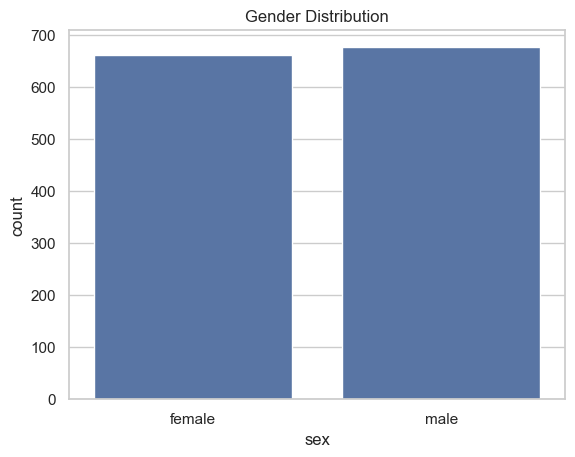

In [14]:
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

- ### Almost equal distribution of male and female.

## Smoker Distribution

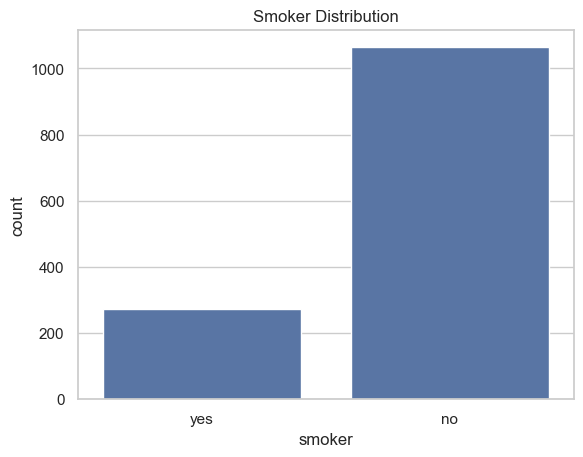

In [17]:
sns.countplot(x='smoker', data=df)
plt.title("Smoker Distribution")
plt.show()

- ### The majority are non-smokers.

- ### Smaller proportion are smokers.

## Region Distribution

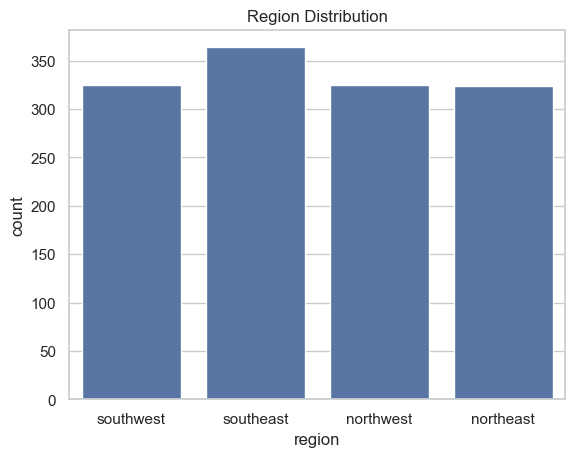

In [18]:
sns.countplot(x='region', data=df)
plt.title("Region Distribution")
plt.show()

- ### Data is evenly distributed across regions.

# Bivariate Analysis

## Smoker vs Charges

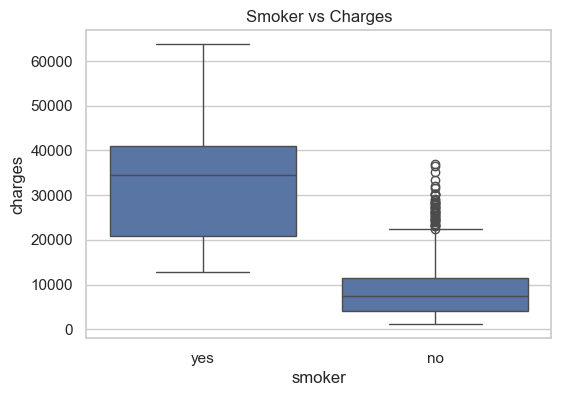

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()

- ### Smokers have significantly higher charges.

- ### Smoking is the strongest factor affecting medical cost.

- ### Insurance company should charge higher premiums for smokers.

## Age vs Charges

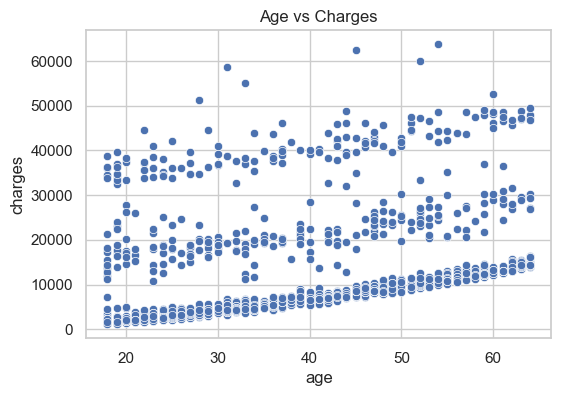

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

- ### Positive correlation observed.

- ### Charges increase as age increases.

## BMI vs Charges

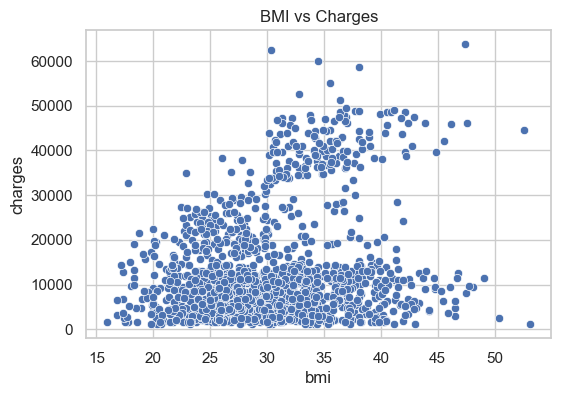

In [22]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

- ### Slight positive relationship.

- ### Very high BMI linked with higher medical expenses.

# Multivariate Analysis

## Correlation Heatmap

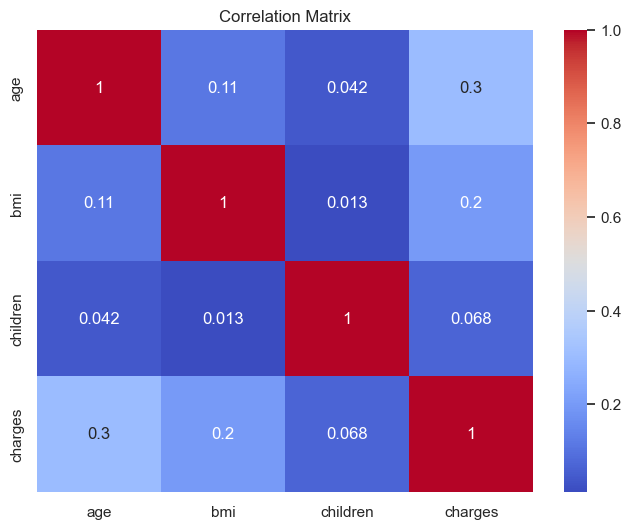

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Correlation Values with Charges:

- ### Age vs Charges → 0.30

- ### BMI vs Charges → 0.20

- ### Children vs Charges → 0.068

## 1. Age vs Charges (0.30)

- ### There is a moderate positive correlation between age and medical charges.

- ### As age increases, medical expenses tend to increase.

- ### Among the numerical variables, age is the most significant predictor of charges.

## 2. BMI vs Charges (0.20)

- ### BMI shows a weak to moderate positive correlation with charges.

- ### Higher BMI is associated with slightly higher medical costs.

- ### However, its impact is lower than age.

## 3. Children vs Charges (0.068)

- ### Very weak correlation between number of children and charges.

- ### This indicates that children have minimal impact on medical expenses.

## 4. Relationship Among Independent Variables

- ### Age vs BMI → 0.11 (very weak)

- ### BMI vs Children → 0.013 (almost no correlation)

# Key Insights

- ### Smoking status is the most influential factor.

- ### Older individuals incur higher medical costs.

- ### High BMI increases risk.

- ### Region has negligible impact.